# Innovation Modeling Notebook

This notebook studies the innovation distribution underlying the VAR/BVAR system and prepares the transition from Gaussian forecasting models to flexible shock-generation models.

Up to this point, the forecasting pipeline has assumed that innovations are Gaussian:

$
y_t = c + A_1 y_{t-1} + \dots + A_p y_{t-p} + u_t,
\qquad
u_t \sim \mathcal{N}(0,\Sigma)
$

That assumption is convenient, but it is often too restrictive in practice. In many macroeconomic and financial settings, innovations may exhibit:

- heavy tails
- skewness
- asymmetry
- multimodality
- distributional instability over time

The goal of this notebook is to examine the innovation process directly and build the bridge toward richer shock models.

## Main goals

This notebook will cover:

1. Extract innovations from fitted VAR/BVAR models
2. Diagnose whether Gaussian innovations are reasonable
3. Compare empirical innovations against:
   - Gaussian benchmarks
   - Student-$t$ innovations
   - bootstrap innovations
4. Study tail behavior and dependence structure
5. Build a foundation for generative shock modeling in the next notebook

## Role in the thesis pipeline

This notebook sits between the Bayesian forecasting machinery and the later generative/DRO components:

- `02_bvar_mechanics` established Gaussian VAR/BVAR forecasting
- `03_innovation_modeling` studies whether Gaussian innovations are adequate
- `04_diffusion_residual_generator` will learn a flexible innovation law
- `05_dro_forecasting` will build robust forecasts under distributional uncertainty

## Immediate objective

We begin by loading the standard scientific Python stack and setting up a reproducible environment for innovation diagnostics and residual modeling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle

from pathlib import Path
from datetime import datetime

from scipy.stats import (
    norm,
    t,
    jarque_bera,
    skew,
    kurtosis,
    probplot
)

# Optional: if statsmodels is available, we can use ACF helpers later
try:
    from statsmodels.tsa.stattools import acf
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False

# -----------------------------------------------------------------------------
# Global reproducibility
# -----------------------------------------------------------------------------
GLOBAL_SEED = 123
rng = np.random.default_rng(GLOBAL_SEED)

print("=" * 80)
print("INNOVATION MODELING NOTEBOOK SETUP")
print("=" * 80)
print(f"Global seed: {GLOBAL_SEED}")
print(f"statsmodels available: {STATSMODELS_AVAILABLE}")
print()

# -----------------------------------------------------------------------------
# Plot settings
# -----------------------------------------------------------------------------
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Imports loaded successfully.")
print("Ready to load or recreate the fitted VAR/BVAR objects and extract innovations.")

INNOVATION MODELING NOTEBOOK SETUP
Global seed: 123
statsmodels available: True

Imports loaded successfully.
Ready to load or recreate the fitted VAR/BVAR objects and extract innovations.


## Recreate Core Utilities and Simulated Benchmark Data

To keep this notebook self-contained and reproducible, we first recreate the core helper functions from the previous notebooks.

We need these utilities for three tasks:

1. simulate a stable benchmark VAR dataset
2. rebuild the regression matrices used in estimation
3. extract fitted innovations from OLS VAR and BVAR models

Using the same simulated benchmark as before is helpful because:

- the true innovation law is known
- we can compare fitted residuals to the true shocks
- later, when we move to non-Gaussian innovation models, we can see clearly what changes

In this notebook, we will begin with the same stable VAR$(2)$ data-generating process used earlier and then fit benchmark models whose residuals will be analyzed.

SIMULATED BENCHMARK DATA
Stable VAR: True
Max eigenvalue modulus: 0.4650
Data shape: (300, 3)
True retained shock shape: (300, 3)

First few observations:


,y1,y2,y3
time,,,
0,0.551738,-0.703764,0.380809
1,-1.110253,-2.564039,-1.328354
2,-1.040441,-0.507790,0.476514
3,-0.627772,-1.469973,-0.671117
4,-0.288088,-0.916778,-0.020670


First few true retained shocks:


,u1,u2,u3
time,,,
0,0.567301,-0.624148,0.443953
1,-1.227170,-2.473848,-1.430347
2,-0.137603,0.600609,1.208335
3,-0.212406,-1.647092,-0.864441
4,-0.059119,-0.306456,0.460892


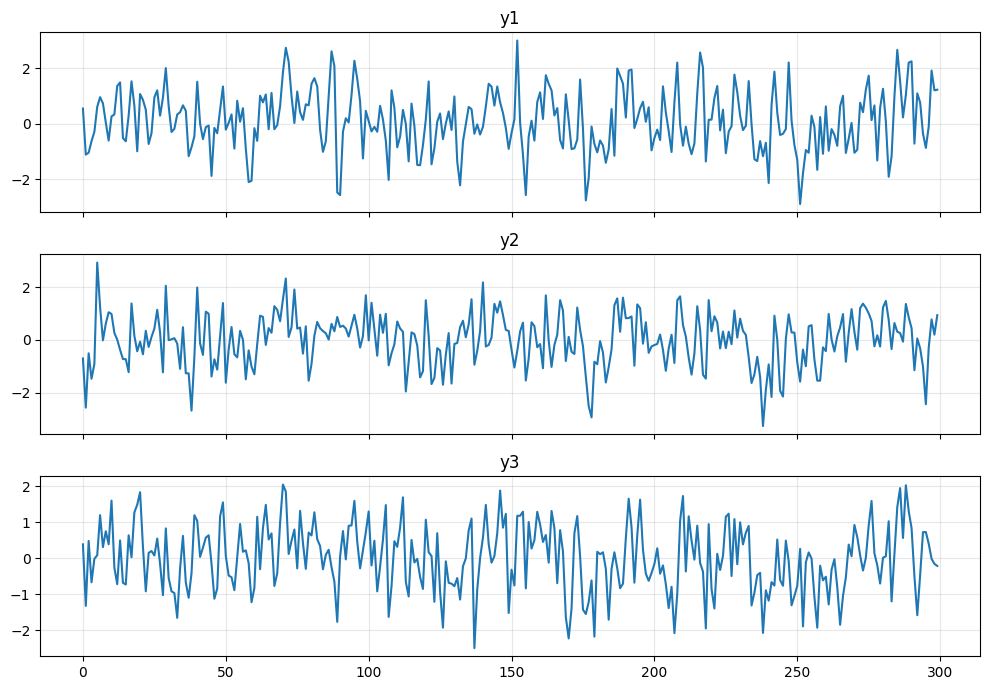

In [2]:
# -----------------------------------------------------------------------------
# Core helper functions reused from previous notebooks
# -----------------------------------------------------------------------------
def companion_matrix(A_list):
    p = len(A_list)
    k = A_list[0].shape[0]

    top_block = np.hstack(A_list)

    if p == 1:
        return top_block

    lower_block = np.hstack([
        np.eye(k * (p - 1)),
        np.zeros((k * (p - 1), k))
    ])

    return np.vstack([top_block, lower_block])


def is_var_stable(A_list, tol=0.999):
    F = companion_matrix(A_list)
    eigvals = np.linalg.eigvals(F)
    max_modulus = np.max(np.abs(eigvals))
    return max_modulus < tol, max_modulus, eigvals


def simulate_var(A_list, Sigma, T, burnin=200, seed=123, return_shocks=False):
    """
    Simulate a stable VAR(p).

    Parameters
    ----------
    A_list : list of np.ndarray
        VAR coefficient matrices.
    Sigma : np.ndarray
        Innovation covariance matrix.
    T : int
        Number of retained observations.
    burnin : int
        Burn-in observations discarded.
    seed : int
        Random seed.
    return_shocks : bool
        If True, also return the retained innovation sequence.

    Returns
    -------
    Y : np.ndarray
        Simulated observations of shape (T, k).
    shocks_retained : np.ndarray, optional
        Retained innovations of shape (T, k).
    """
    local_rng = np.random.default_rng(seed)

    p = len(A_list)
    k = A_list[0].shape[0]
    total_T = T + burnin

    Y = np.zeros((total_T + p, k))
    shocks = local_rng.multivariate_normal(
        mean=np.zeros(k),
        cov=Sigma,
        size=total_T
    )

    for t in range(p, total_T + p):
        y_t = np.zeros(k)

        for lag in range(1, p + 1):
            y_t += A_list[lag - 1] @ Y[t - lag]

        y_t += shocks[t - p]
        Y[t] = y_t

    Y_retained = Y[p + burnin:]
    shocks_retained = shocks[burnin:]

    if return_shocks:
        return Y_retained, shocks_retained
    return Y_retained


def build_var_regression_matrices(Y, p, include_intercept=True):
    Y = np.asarray(Y)
    T, k = Y.shape

    if T <= p:
        raise ValueError(f"Need T > p, but got T={T}, p={p}")

    X_rows = []
    Y_rows = []
    feature_names = []

    if include_intercept:
        feature_names.append("const")

    for lag in range(1, p + 1):
        for j in range(k):
            feature_names.append(f"y{j+1}_lag{lag}")

    for t in range(p, T):
        row = []

        if include_intercept:
            row.append(1.0)

        for lag in range(1, p + 1):
            row.extend(Y[t - lag, :])

        X_rows.append(row)
        Y_rows.append(Y[t, :])

    X = np.array(X_rows)
    Y_target = np.array(Y_rows)

    return Y_target, X, feature_names


def extract_var_coefficients(B, k, p, include_intercept=True):
    row_idx = 0
    intercept = None

    if include_intercept:
        intercept = B[0, :]
        row_idx = 1

    A_list = []
    for lag in range(p):
        block = B[row_idx + lag * k : row_idx + (lag + 1) * k, :]
        A_list.append(block.T)

    return intercept, A_list


def fit_var_ols(Y, p, include_intercept=True):
    Y_target, X, feature_names = build_var_regression_matrices(
        Y=Y,
        p=p,
        include_intercept=include_intercept
    )

    XtX = X.T @ X
    XtY = X.T @ Y_target
    B_hat = np.linalg.solve(XtX, XtY)

    fitted_values = X @ B_hat
    residuals = Y_target - fitted_values

    T_eff, k_local = Y_target.shape
    Sigma_hat = (residuals.T @ residuals) / T_eff

    intercept_hat, A_hat_list = extract_var_coefficients(
        B_hat,
        k=k_local,
        p=p,
        include_intercept=include_intercept
    )

    return {
        "B_hat": B_hat,
        "residuals": residuals,
        "Sigma_hat": Sigma_hat,
        "Y_target": Y_target,
        "X": X,
        "feature_names": feature_names,
        "intercept": intercept_hat,
        "A_hat_list": A_hat_list,
        "fitted_values": fitted_values,
    }


# -----------------------------------------------------------------------------
# Recreate the same simulated stable VAR(2) benchmark data
# -----------------------------------------------------------------------------
k = 3
p = 2
T = 300

A1 = np.array([
    [0.50, 0.10, 0.00],
    [0.05, 0.40, 0.10],
    [0.00, 0.10, 0.35]
])

A2 = np.array([
    [-0.20, 0.00, 0.05],
    [0.00, -0.15, 0.00],
    [0.05, 0.00, -0.10]
])

Sigma = np.array([
    [1.00, 0.30, 0.20],
    [0.30, 0.80, 0.25],
    [0.20, 0.25, 0.60]
])

stable, max_modulus, eigvals = is_var_stable([A1, A2])

print("=" * 80)
print("SIMULATED BENCHMARK DATA")
print("=" * 80)
print(f"Stable VAR: {stable}")
print(f"Max eigenvalue modulus: {max_modulus:.4f}")

if not stable:
    raise ValueError("Chosen benchmark DGP is not stable.")

Y, true_shocks = simulate_var(
    [A1, A2],
    Sigma,
    T=T,
    burnin=300,
    seed=GLOBAL_SEED,
    return_shocks=True
)

columns = [f"y{i+1}" for i in range(k)]
df = pd.DataFrame(Y, columns=columns)
df.index.name = "time"

true_shocks_df = pd.DataFrame(
    true_shocks,
    columns=[f"u{i+1}" for i in range(k)]
)
true_shocks_df.index.name = "time"

print(f"Data shape: {df.shape}")
print(f"True retained shock shape: {true_shocks_df.shape}")
print()

print("First few observations:")
display(df.head())

print("First few true retained shocks:")
display(true_shocks_df.head())

fig, axes = plt.subplots(k, 1, figsize=(10, 7), sharex=True)
for i, col in enumerate(columns):
    axes[i].plot(df.index, df[col])
    axes[i].set_title(col)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Fit Benchmark VAR Model and Extract Innovations

We now fit a benchmark VAR model using ordinary least squares and extract the fitted innovations.

Given the VAR model

$
y_t = c + A_1 y_{t-1} + \dots + A_p y_{t-p} + u_t
$

the innovations can be recovered from the fitted model as

$
\hat u_t = y_t - \hat c - \hat A_1 y_{t-1} - \dots - \hat A_p y_{t-p}.
$

These residuals represent the **estimated innovation sequence** implied by the fitted VAR model.

Because we simulated the data earlier, we also have access to the **true retained shocks** used in the data-generating process. This allows us to directly compare:

- true innovations from the simulation
- estimated innovations from the fitted VAR

If the VAR is correctly specified and the sample size is sufficiently large, the estimated innovations should resemble the true shocks.

VAR ESTIMATION COMPLETE
Residual matrix shape: (298, 3)

First few estimated innovations:


,u_hat1,u_hat2,u_hat3
time,,,
2,-0.308586,0.400655,1.156647
3,-0.454226,-1.451371,-0.845491
4,-0.271755,-0.367548,0.386183
5,0.621114,3.117073,0.129438
6,0.220443,0.266284,0.845639


First few true innovations (from simulation):


,u1,u2,u3
time,,,
2,-0.137603,0.600609,1.208335
3,-0.212406,-1.647092,-0.864441
4,-0.059119,-0.306456,0.460892
5,0.756624,3.088316,0.143117
6,0.306461,-0.102125,0.884198


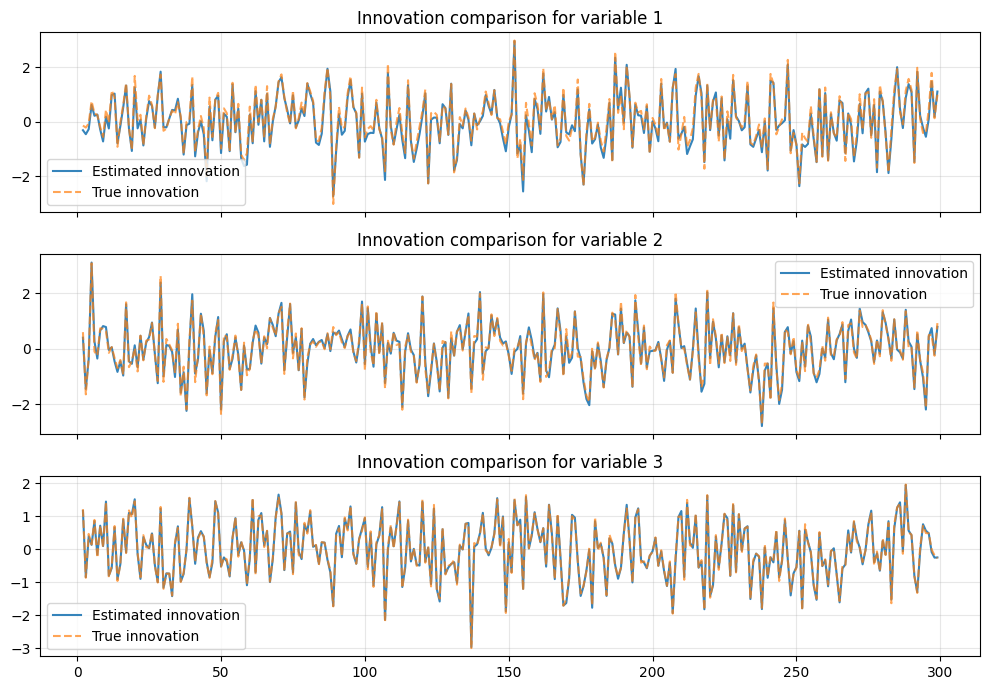

In [3]:
# -----------------------------------------------------------------------------
# Fit benchmark VAR(p) using OLS
# -----------------------------------------------------------------------------
var_fit = fit_var_ols(
    df.values,
    p=p,
    include_intercept=True
)

var_residuals = var_fit["residuals"]

print("=" * 80)
print("VAR ESTIMATION COMPLETE")
print("=" * 80)
print(f"Residual matrix shape: {var_residuals.shape}")
print()

# Convert residuals to DataFrame
residuals_df = pd.DataFrame(
    var_residuals,
    columns=[f"u_hat{i+1}" for i in range(k)]
)

# Align time index (residuals start at t=p)
residuals_df.index = df.index[p:]
residuals_df.index.name = "time"

print("First few estimated innovations:")
display(residuals_df.head())

# Align true shocks for comparison
true_shocks_aligned = true_shocks_df.iloc[p:].copy()

print("First few true innovations (from simulation):")
display(true_shocks_aligned.head())

# -----------------------------------------------------------------------------
# Quick comparison plots
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(k, 1, figsize=(10, 7), sharex=True)

for j in range(k):
    axes[j].plot(
        residuals_df.index,
        residuals_df.iloc[:, j],
        label="Estimated innovation",
        alpha=0.9
    )

    axes[j].plot(
        true_shocks_aligned.index,
        true_shocks_aligned.iloc[:, j],
        linestyle="--",
        label="True innovation",
        alpha=0.7
    )

    axes[j].set_title(f"Innovation comparison for variable {j+1}")
    axes[j].legend()
    axes[j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Innovation Distribution Diagnostics

Before replacing the Gaussian innovation assumption, we should test whether it is reasonable for the estimated residuals.

For each innovation series $\hat u_t$, we compute several standard diagnostics:

1. **Mean and variance**  
   Check that the residuals are approximately centered.

2. **Skewness**  
   Measures asymmetry of the distribution.

   $
   \text{skew}(u) = E\left[\left(\frac{u-\mu}{\sigma}\right)^3\right]
   $

3. **Kurtosis**  
   Measures tail thickness relative to the Gaussian distribution.

   $
   \text{kurt}(u) = E\left[\left(\frac{u-\mu}{\sigma}\right)^4\right]
   $

   For a Gaussian distribution:

   $
   \text{kurtosis} = 3
   $

   Excess kurtosis is therefore:

   $
   \text{kurtosis} - 3
   $

4. **Jarque–Bera test**

   This test jointly evaluates skewness and kurtosis deviations from Gaussianity.

   $
   JB = \frac{T}{6}\left(S^2 + \frac{(K-3)^2}{4}\right)
   $

If the Gaussian assumption is correct, we should observe:

- skewness near 0  
- kurtosis near 3  
- Jarque–Bera p-values not rejecting normality

INNOVATION DISTRIBUTION DIAGNOSTICS


,variable,mean,std,skewness,kurtosis,excess_kurtosis,jarque_bera_stat,jarque_bera_p
0,u_hat1,0.0,0.9630,-0.0037,2.8988,-0.1012,0.1278,0.9381
1,u_hat2,0.0,0.9118,-0.0528,3.3071,0.3071,1.3098,0.5195
2,u_hat3,0.0,0.8544,-0.2238,2.7421,-0.2579,3.3129,0.1908


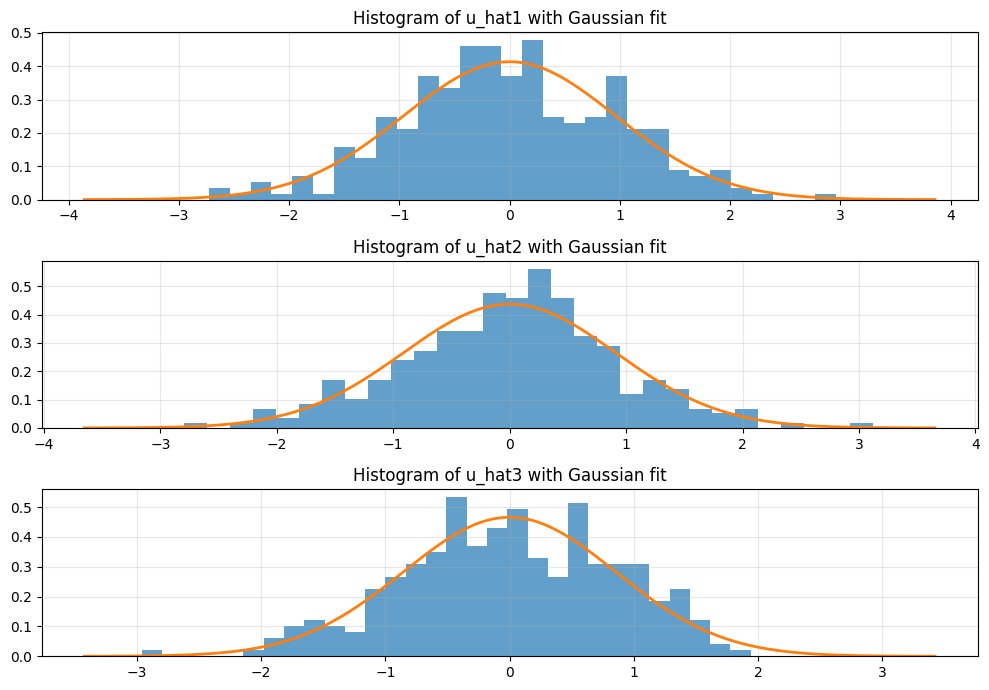

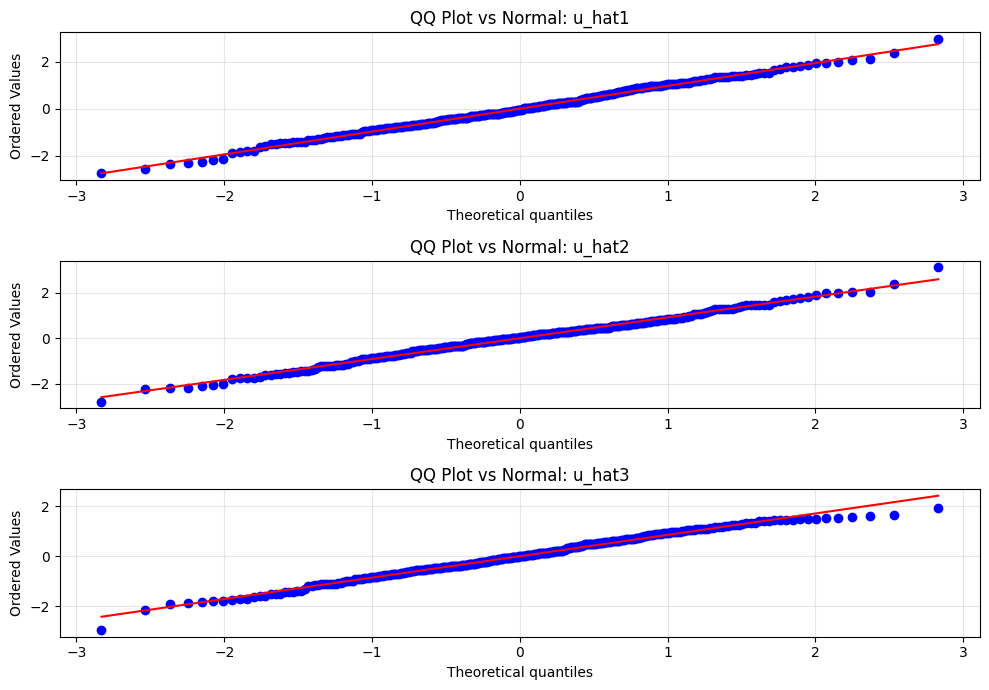

In [4]:
# -----------------------------------------------------------------------------
# Innovation distribution diagnostics
# -----------------------------------------------------------------------------
def innovation_diagnostics(residuals_df):
    results = []

    for col in residuals_df.columns:
        series = residuals_df[col].values

        mean_val = np.mean(series)
        std_val = np.std(series)
        skew_val = skew(series)
        kurt_val = kurtosis(series, fisher=False)  # Pearson kurtosis
        jb_stat, jb_p = jarque_bera(series)

        results.append({
            "variable": col,
            "mean": mean_val,
            "std": std_val,
            "skewness": skew_val,
            "kurtosis": kurt_val,
            "excess_kurtosis": kurt_val - 3,
            "jarque_bera_stat": jb_stat,
            "jarque_bera_p": jb_p
        })

    return pd.DataFrame(results)


diagnostics_df = innovation_diagnostics(residuals_df)

print("=" * 80)
print("INNOVATION DISTRIBUTION DIAGNOSTICS")
print("=" * 80)

display(diagnostics_df.round(4))


# -----------------------------------------------------------------------------
# Visual diagnostics: histograms
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(k, 1, figsize=(10, 7))

for j, col in enumerate(residuals_df.columns):

    axes[j].hist(
        residuals_df[col],
        bins=30,
        density=True,
        alpha=0.7
    )

    # Overlay Gaussian fit
    mu = residuals_df[col].mean()
    sigma = residuals_df[col].std()

    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    axes[j].plot(x, norm.pdf(x, mu, sigma), linewidth=2)

    axes[j].set_title(f"Histogram of {col} with Gaussian fit")

plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# QQ plots against Gaussian
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(k, 1, figsize=(10, 7))

for j, col in enumerate(residuals_df.columns):
    probplot(residuals_df[col], dist="norm", plot=axes[j])
    axes[j].set_title(f"QQ Plot vs Normal: {col}")

plt.tight_layout()
plt.show()

## Innovation Dependence Diagnostics

In addition to marginal distribution shape, it is important to understand the **dependence structure** of the innovations.

For a well-specified VAR, the fitted innovations should ideally behave like white noise:

- little remaining serial correlation within each innovation series
- contemporaneous cross-correlation may remain, captured by $\Sigma$
- little cross-lag dependence after conditioning on the VAR dynamics

We examine two aspects:

1. **Autocorrelation of each estimated innovation series**  
   This checks whether the VAR has removed most temporal dependence.

2. **Contemporaneous correlation across innovation series**  
   This checks the cross-sectional dependence structure of the shocks.

If substantial serial dependence remains, then the VAR dynamics may still be misspecified.

INNOVATION CORRELATION DIAGNOSTICS
Contemporaneous correlation matrix of estimated innovations:


,u_hat1,u_hat2,u_hat3
u_hat1,1.0000,0.3580,0.2767
u_hat2,0.3580,1.0000,0.3704
u_hat3,0.2767,0.3704,1.0000


Correlation implied by estimated Sigma_hat:


,u_hat1,u_hat2,u_hat3
u_hat1,1.0000,0.3580,0.2767
u_hat2,0.3580,1.0000,0.3704
u_hat3,0.2767,0.3704,1.0000


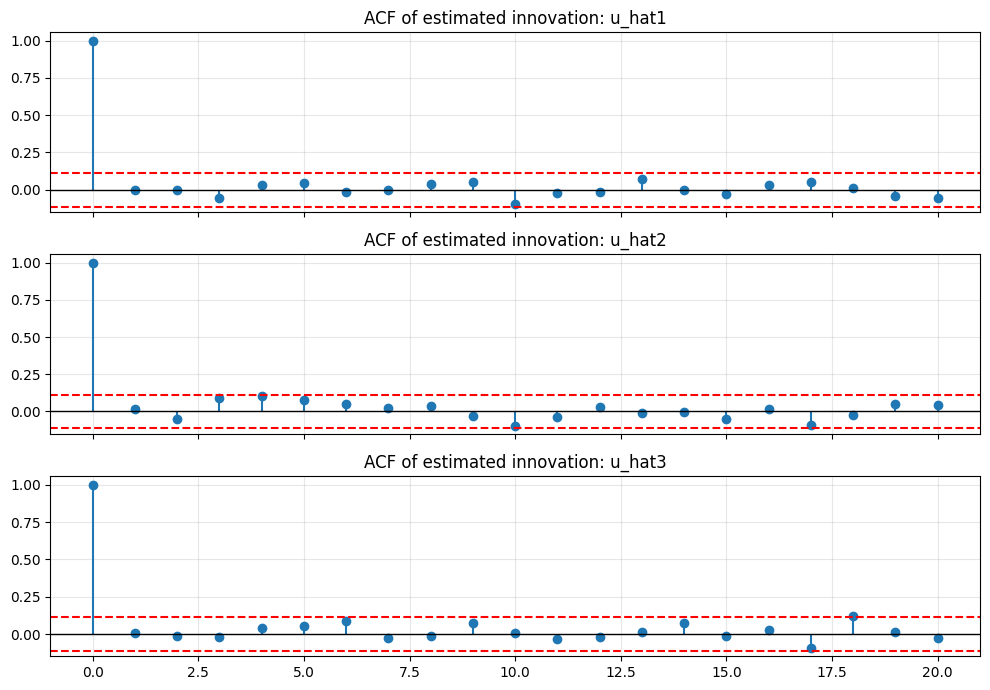

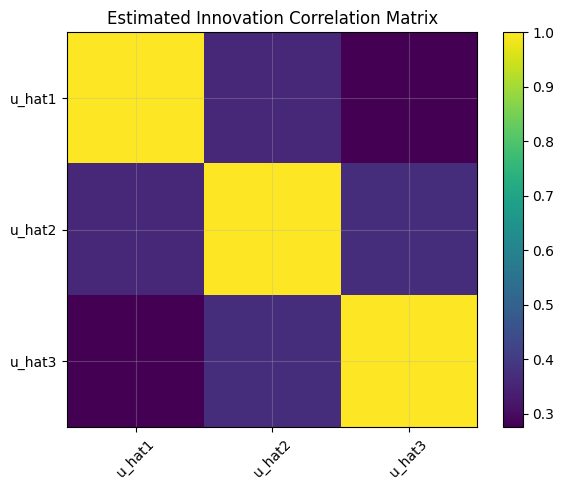

In [5]:
# -----------------------------------------------------------------------------
# Innovation dependence diagnostics
# -----------------------------------------------------------------------------
def simple_acf(x, max_lag=20):
    """
    Compute sample autocorrelation function up to max_lag.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)

    if denom <= 0:
        return np.zeros(max_lag + 1)

    acf_vals = [1.0]
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acf_vals.append(num / denom)

    return np.array(acf_vals)


max_lag = 20

print("=" * 80)
print("INNOVATION CORRELATION DIAGNOSTICS")
print("=" * 80)

# Contemporaneous correlation matrix
innovation_corr = residuals_df.corr()

print("Contemporaneous correlation matrix of estimated innovations:")
display(innovation_corr.round(4))

# Compare with estimated Sigma_hat converted to correlation
sigma_hat = var_fit["Sigma_hat"]
sigma_std = np.sqrt(np.diag(sigma_hat))
sigma_corr = sigma_hat / np.outer(sigma_std, sigma_std)

print("Correlation implied by estimated Sigma_hat:")
display(pd.DataFrame(
    sigma_corr,
    index=residuals_df.columns,
    columns=residuals_df.columns
).round(4))

# -----------------------------------------------------------------------------
# ACF plots for each innovation series
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(k, 1, figsize=(10, 7), sharex=True)

for j, col in enumerate(residuals_df.columns):
    series = residuals_df[col].values

    if STATSMODELS_AVAILABLE:
        acf_vals = acf(series, nlags=max_lag, fft=False)
    else:
        acf_vals = simple_acf(series, max_lag=max_lag)

    lags = np.arange(len(acf_vals))

    axes[j].stem(lags, acf_vals, basefmt=" ")
    axes[j].axhline(0.0, color="black", linewidth=1)
    axes[j].axhline(1.96 / np.sqrt(len(series)), linestyle="--", color="red")
    axes[j].axhline(-1.96 / np.sqrt(len(series)), linestyle="--", color="red")
    axes[j].set_title(f"ACF of estimated innovation: {col}")
    axes[j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Cross-correlation heatmap-style table
# -----------------------------------------------------------------------------
plt.figure(figsize=(6, 5))
plt.imshow(innovation_corr.values, aspect="auto")
plt.xticks(range(k), residuals_df.columns, rotation=45)
plt.yticks(range(k), residuals_df.columns)
plt.title("Estimated Innovation Correlation Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

## Comparing Estimated Innovations to Alternative Reference Distributions

The previous diagnostics tell us whether the estimated innovations look approximately Gaussian, but it is also useful to compare them against alternative benchmark distributions.

In this section we compare the fitted innovations to three reference models:

1. **Gaussian benchmark**  
   Matches the sample mean and standard deviation.

2. **Student-$t$ benchmark**  
   Allows heavier tails than the Gaussian distribution.

3. **Bootstrap benchmark**  
   Uses the empirical residual distribution directly through resampling.

This is not yet the final shock model. Instead, it is a diagnostic step that helps answer:

- Are the innovations more heavy-tailed than Gaussian?
- Is a simple heavy-tailed parametric benchmark already better?
- How different is the empirical innovation law from a smooth Gaussian fit?

We start by fitting a univariate Student-$t$ distribution to each innovation series and comparing density overlays.

REFERENCE DISTRIBUTION FITS


,variable,gaussian_mean,gaussian_std,t_df,t_loc,t_scale
0,u_hat1,0.0,0.9646,8.777023e+10,0.0000,0.9630
1,u_hat2,0.0,0.9133,1.683800e+01,0.0038,0.8567
2,u_hat3,0.0,0.8559,6.910218e+12,-0.0000,0.8544


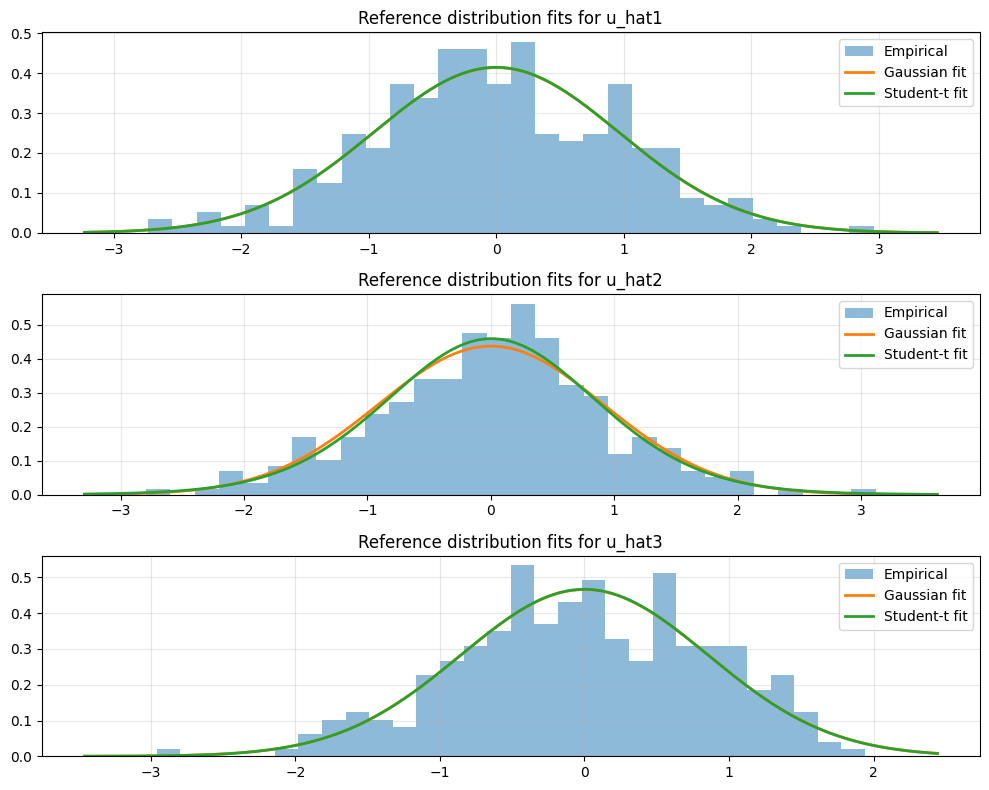

BOOTSTRAP INNOVATION PREVIEW


,u_hat1,u_hat2,u_hat3
0,0.220443,0.266284,0.845639
1,-0.030621,-0.033626,-1.113905
2,0.459062,-2.038362,-0.014167
3,-0.253179,-0.452474,1.097347
4,0.655857,1.453047,0.041947


In [6]:
from scipy.stats import t as student_t

# -----------------------------------------------------------------------------
# Fit simple reference distributions to each innovation series
# -----------------------------------------------------------------------------
def fit_univariate_references(residuals_df):
    """
    Fit Gaussian and Student-t reference distributions to each innovation series.
    """
    fitted = {}

    for col in residuals_df.columns:
        x = residuals_df[col].values.astype(float)

        mu_hat = np.mean(x)
        sigma_hat = np.std(x, ddof=1)

        # Student-t fit: returns (df, loc, scale)
        t_df, t_loc, t_scale = student_t.fit(x)

        fitted[col] = {
            "gaussian_mean": mu_hat,
            "gaussian_std": sigma_hat,
            "t_df": t_df,
            "t_loc": t_loc,
            "t_scale": t_scale
        }

    return fitted


reference_fits = fit_univariate_references(residuals_df)

print("=" * 80)
print("REFERENCE DISTRIBUTION FITS")
print("=" * 80)

reference_rows = []
for col, fit_dict in reference_fits.items():
    reference_rows.append({
        "variable": col,
        "gaussian_mean": fit_dict["gaussian_mean"],
        "gaussian_std": fit_dict["gaussian_std"],
        "t_df": fit_dict["t_df"],
        "t_loc": fit_dict["t_loc"],
        "t_scale": fit_dict["t_scale"]
    })

reference_df = pd.DataFrame(reference_rows)
display(reference_df.round(4))

# -----------------------------------------------------------------------------
# Density overlays: empirical histogram vs Gaussian vs Student-t
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(k, 1, figsize=(10, 8))

for j, col in enumerate(residuals_df.columns):
    x = residuals_df[col].values
    fit_dict = reference_fits[col]

    mu_hat = fit_dict["gaussian_mean"]
    sigma_hat = fit_dict["gaussian_std"]
    t_df = fit_dict["t_df"]
    t_loc = fit_dict["t_loc"]
    t_scale = fit_dict["t_scale"]

    x_grid = np.linspace(np.min(x) - 0.5, np.max(x) + 0.5, 400)

    axes[j].hist(x, bins=30, density=True, alpha=0.5, label="Empirical")
    axes[j].plot(
        x_grid,
        norm.pdf(x_grid, loc=mu_hat, scale=sigma_hat),
        linewidth=2,
        label="Gaussian fit"
    )
    axes[j].plot(
        x_grid,
        student_t.pdf(x_grid, df=t_df, loc=t_loc, scale=t_scale),
        linewidth=2,
        label="Student-t fit"
    )

    axes[j].set_title(f"Reference distribution fits for {col}")
    axes[j].legend()
    axes[j].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Bootstrap innovation sampler preview
# -----------------------------------------------------------------------------
def bootstrap_innovation_sample(residuals_df, n_samples, seed=123):
    """
    Resample innovations row-wise from the empirical residual matrix.
    """
    local_rng = np.random.default_rng(seed)
    idx = local_rng.choice(len(residuals_df), size=n_samples, replace=True)
    return residuals_df.iloc[idx].reset_index(drop=True)


bootstrap_preview = bootstrap_innovation_sample(
    residuals_df,
    n_samples=5,
    seed=GLOBAL_SEED
)

print("=" * 80)
print("BOOTSTRAP INNOVATION PREVIEW")
print("=" * 80)
display(bootstrap_preview)

## Innovation Covariance Structure and Shock Geometry

Up to this point we examined the marginal distribution of each innovation component.  
However, VAR innovations are **multivariate shocks**, and their joint dependence structure is crucial.

Recall the VAR innovation model

$
u_t \sim (0,\Sigma)
$

where

$
\Sigma = E[u_t u_t']
$

captures contemporaneous dependence between variables.

Even if the marginal distributions were Gaussian, the **joint geometry of the shock distribution** could still be complex. Understanding this covariance structure is important for three reasons:

1. **Shock propagation in the VAR**

   The covariance matrix determines how innovations affect the system through

   $
   y_t = c + A_1 y_{t-1} + \dots + A_p y_{t-p} + u_t.
   $

2. **Stress testing**

   Extreme shocks typically occur along directions associated with large eigenvalues of $\Sigma$.

3. **Future generative modeling**

   In the diffusion-based generator (next notebook), we will learn the full joint distribution of innovations.  
   Understanding the covariance geometry helps verify whether the learned model captures realistic dependence patterns.

We therefore examine:

- the innovation covariance matrix
- eigenvalues and principal directions of the shock distribution
- a simple visualization of the innovation cloud

ESTIMATED INNOVATION COVARIANCE MATRIX


,u_hat1,u_hat2,u_hat3
u_hat1,0.9305,0.3154,0.2284
u_hat2,0.3154,0.8341,0.2895
u_hat3,0.2284,0.2895,0.7325


INNOVATION COVARIANCE EIGENSTRUCTURE


,eigenvalue
0,0.485253
1,0.612324
2,1.399551


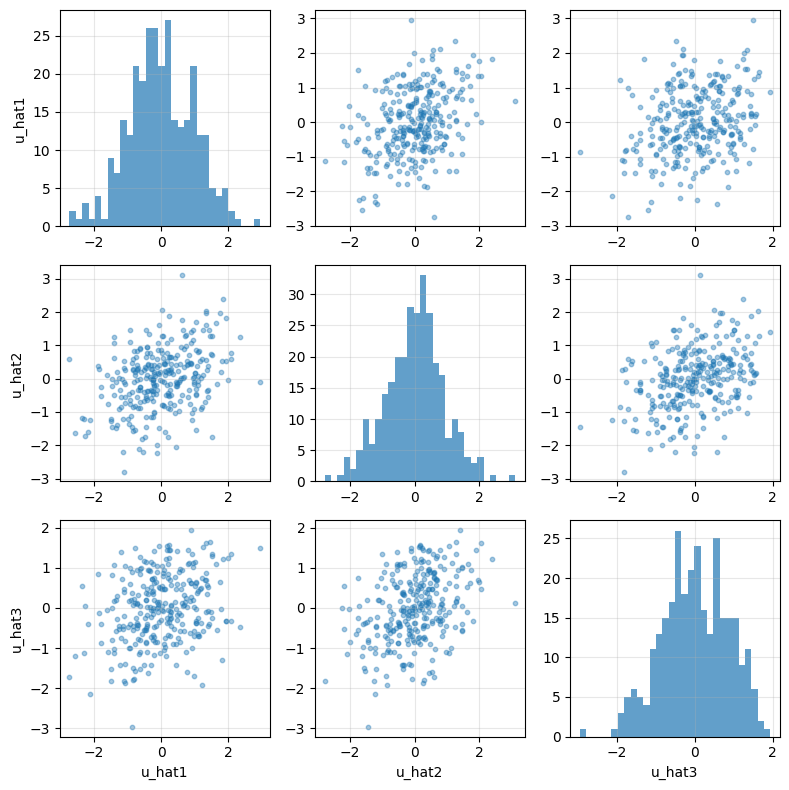

PRINCIPAL SHOCK DIRECTIONS


,eigvec_1,eigvec_2,eigvec_3
u_hat1,0.1445,-0.7560,-0.6384
u_hat2,-0.7060,0.3732,-0.6018
u_hat3,0.6933,0.5377,-0.4798


In [7]:
# -----------------------------------------------------------------------------
# Innovation covariance analysis
# -----------------------------------------------------------------------------
innovation_cov = np.cov(residuals_df.values.T)

print("=" * 80)
print("ESTIMATED INNOVATION COVARIANCE MATRIX")
print("=" * 80)

innovation_cov_df = pd.DataFrame(
    innovation_cov,
    index=residuals_df.columns,
    columns=residuals_df.columns
)

display(innovation_cov_df.round(4))


# -----------------------------------------------------------------------------
# Eigen-decomposition of covariance
# -----------------------------------------------------------------------------
eigvals, eigvecs = np.linalg.eigh(innovation_cov)

print("=" * 80)
print("INNOVATION COVARIANCE EIGENSTRUCTURE")
print("=" * 80)

eig_summary = pd.DataFrame({
    "eigenvalue": eigvals,
})

display(eig_summary.round(6))


# -----------------------------------------------------------------------------
# Visualize innovation cloud (pairwise scatter)
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(k, k, figsize=(8, 8))

for i in range(k):
    for j in range(k):

        ax = axes[i, j]

        if i == j:
            ax.hist(residuals_df.iloc[:, i], bins=30, alpha=0.7)
        else:
            ax.scatter(
                residuals_df.iloc[:, j],
                residuals_df.iloc[:, i],
                alpha=0.4,
                s=10
            )

        if i == k - 1:
            ax.set_xlabel(residuals_df.columns[j])

        if j == 0:
            ax.set_ylabel(residuals_df.columns[i])

plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# Principal shock directions
# -----------------------------------------------------------------------------
print("=" * 80)
print("PRINCIPAL SHOCK DIRECTIONS")
print("=" * 80)

principal_dirs = pd.DataFrame(
    eigvecs,
    index=residuals_df.columns,
    columns=[f"eigvec_{i+1}" for i in range(k)]
)

display(principal_dirs.round(4))

## Generating Synthetic Innovation Sequences

The previous sections studied the empirical innovation distribution and compared it against simple parametric benchmarks.  
We now construct **synthetic innovation generators** that will later be used for:

- scenario simulation
- stress testing
- distributional robustness experiments
- training generative models

We implement three innovation generators:

1. **Gaussian generator**

   $
   u_t \sim \mathcal{N}(0,\hat\Sigma)
   $

2. **Student-t generator**

   $
   u_t \sim t_\nu(0,\Sigma)
   $

   which allows heavy tails.

3. **Bootstrap generator**

   $
   u_t \sim \text{Empirical}(\hat u_1,\dots,\hat u_T)
   $

These generators allow us to compare **forecast behavior under different shock distributions** before moving to the diffusion-based generator in the next notebook.

SYNTHETIC SHOCK GENERATION
Gaussian shocks shape: (300, 3)
Student-t shocks shape: (300, 3)
Bootstrap shocks shape: (300, 3)


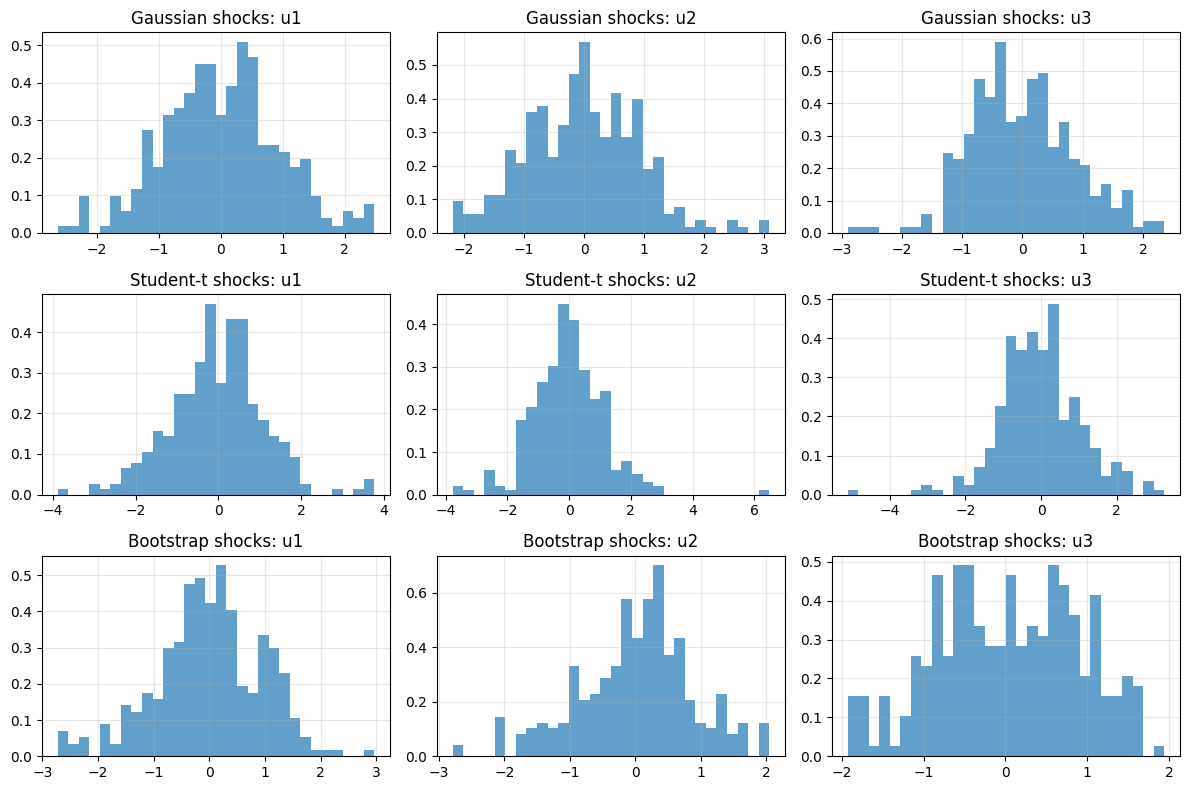

In [8]:
# -----------------------------------------------------------------------------
# Synthetic innovation generators
# -----------------------------------------------------------------------------

def generate_gaussian_shocks(n, Sigma, seed=123):
    """
    Generate Gaussian innovations.
    """
    rng = np.random.default_rng(seed)
    k = Sigma.shape[0]

    shocks = rng.multivariate_normal(
        mean=np.zeros(k),
        cov=Sigma,
        size=n
    )

    return shocks


def generate_student_t_shocks(n, Sigma, df=5, seed=123):
    """
    Generate multivariate Student-t innovations.
    """
    rng = np.random.default_rng(seed)
    k = Sigma.shape[0]

    g = rng.multivariate_normal(np.zeros(k), Sigma, size=n)
    chi = rng.chisquare(df, size=n)

    shocks = g / np.sqrt(chi[:, None] / df)

    return shocks


def generate_bootstrap_shocks(residuals_df, n, seed=123):
    """
    Resample empirical innovations.
    """
    rng = np.random.default_rng(seed)

    idx = rng.choice(len(residuals_df), size=n, replace=True)
    shocks = residuals_df.values[idx]

    return shocks


# -----------------------------------------------------------------------------
# Generate example shock paths
# -----------------------------------------------------------------------------
n_shocks = 300

gaussian_shocks = generate_gaussian_shocks(
    n_shocks,
    innovation_cov,
    seed=GLOBAL_SEED
)

student_shocks = generate_student_t_shocks(
    n_shocks,
    innovation_cov,
    df=5,
    seed=GLOBAL_SEED
)

bootstrap_shocks = generate_bootstrap_shocks(
    residuals_df,
    n_shocks,
    seed=GLOBAL_SEED
)

print("=" * 80)
print("SYNTHETIC SHOCK GENERATION")
print("=" * 80)
print(f"Gaussian shocks shape: {gaussian_shocks.shape}")
print(f"Student-t shocks shape: {student_shocks.shape}")
print(f"Bootstrap shocks shape: {bootstrap_shocks.shape}")


# -----------------------------------------------------------------------------
# Visual comparison of shock distributions
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(3, k, figsize=(12, 8), sharex=False)

shock_sets = [
    ("Gaussian", gaussian_shocks),
    ("Student-t", student_shocks),
    ("Bootstrap", bootstrap_shocks)
]

for i, (name, shocks) in enumerate(shock_sets):

    for j in range(k):

        axes[i, j].hist(
            shocks[:, j],
            bins=30,
            alpha=0.7,
            density=True
        )

        axes[i, j].set_title(f"{name} shocks: u{j+1}")

plt.tight_layout()
plt.show()

## Innovation Analysis Logging

To make the innovation analysis reproducible and comparable across datasets, we log a compact summary of the diagnostics performed in this notebook.

The logged experiment includes:

- innovation diagnostics (skewness, kurtosis, Jarque–Bera)
- Student-t reference fits
- estimated innovation covariance
- covariance eigenvalues
- experiment configuration

These logs will later allow direct comparison between:

- Gaussian innovations
- heavy-tailed innovations
- bootstrap innovations
- diffusion-generated shocks

All logs are saved to the `logs/` directory and excluded from version control.

In [9]:
# -----------------------------------------------------------------------------
# Innovation experiment logging
# -----------------------------------------------------------------------------

def summarize_innovation_experiment(
    diagnostics_df,
    reference_df,
    innovation_cov,
    eigvals,
    config
):
    summary = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "analysis_type": "innovation_diagnostics",
        "config": config,
        "diagnostics": diagnostics_df.to_dict(orient="records"),
        "reference_fits": reference_df.to_dict(orient="records"),
        "innovation_covariance": innovation_cov.tolist(),
        "covariance_eigenvalues": eigvals.tolist()
    }

    return summary


def save_innovation_log(summary, save_dir="logs"):

    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"innovation_analysis_{timestamp}.json"

    filepath = save_path / filename

    with open(filepath, "w") as f:
        json.dump(summary, f, indent=2)

    return filepath


# -----------------------------------------------------------------------------
# Build experiment summary
# -----------------------------------------------------------------------------

innovation_summary = summarize_innovation_experiment(
    diagnostics_df=diagnostics_df,
    reference_df=reference_df,
    innovation_cov=innovation_cov,
    eigvals=eigvals,
    config={
        "n_observations": int(df.shape[0]),
        "n_variables": int(df.shape[1]),
        "lag_order": p,
        "seed": GLOBAL_SEED
    }
)

log_path = save_innovation_log(innovation_summary)

print("=" * 80)
print("INNOVATION ANALYSIS LOG SAVED")
print("=" * 80)
print(f"Log file: {log_path}")
print()

print("Preview of logged summary:")
print(json.dumps(innovation_summary, indent=2)[:1000], "...")

INNOVATION ANALYSIS LOG SAVED
Log file: logs/innovation_analysis_20260316_130122.json

Preview of logged summary:
{
  "timestamp": "2026-03-16T13:01:22",
  "analysis_type": "innovation_diagnostics",
  "config": {
    "n_observations": 300,
    "n_variables": 3,
    "lag_order": 2,
    "seed": 123
  },
  "diagnostics": [
    {
      "variable": "u_hat1",
      "mean": 3.7255806195475053e-17,
      "std": 0.9630184881646963,
      "skewness": -0.0037322739031962746,
      "kurtosis": 2.8988091491653254,
      "excess_kurtosis": -0.1011908508346746,
      "jarque_bera_stat": 0.12783340476860783,
      "jarque_bera_p": 0.9380831363649622
    },
    {
      "variable": "u_hat2",
      "mean": 8.941393486914012e-18,
      "std": 0.9117614354289839,
      "skewness": -0.05279828202704292,
      "kurtosis": 3.3071452341299215,
      "excess_kurtosis": 0.30714523412992145,
      "jarque_bera_stat": 1.309819629093682,
      "jarque_bera_p": 0.5194889108173352
    },
    {
      "variable": "u_ha